# Лабораторная работа 3

## Часть 1: изюм

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve

**1. Предобработка**

Датасет с изюмом содержит характеристики двух видов изюма (измеренные по их изображениям, в пикселях; можно сказать, вы занимаетесь классификацией изображений!). Порисуйте графики, чтобы составить представление о распределении признаков *внутри класса*. Мы собираемся использовать наивный байесовский классификатор, LDA и QDА. Примените к признакам преобразования, изменяющие распределение там, где посчитаете нужным. Можно ли сразу по вашим графикам сказать, что предположения, нужные для какого-то из классификаторов, здесь совсем не выполняются?

- *чтобы убрать длинный хвост у распределения справа, можно взять корень или логарифм - это мы знаем. Если же длинный хвост у распределения слева, его можно отразить, прежде чем брать логарифмы.*


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


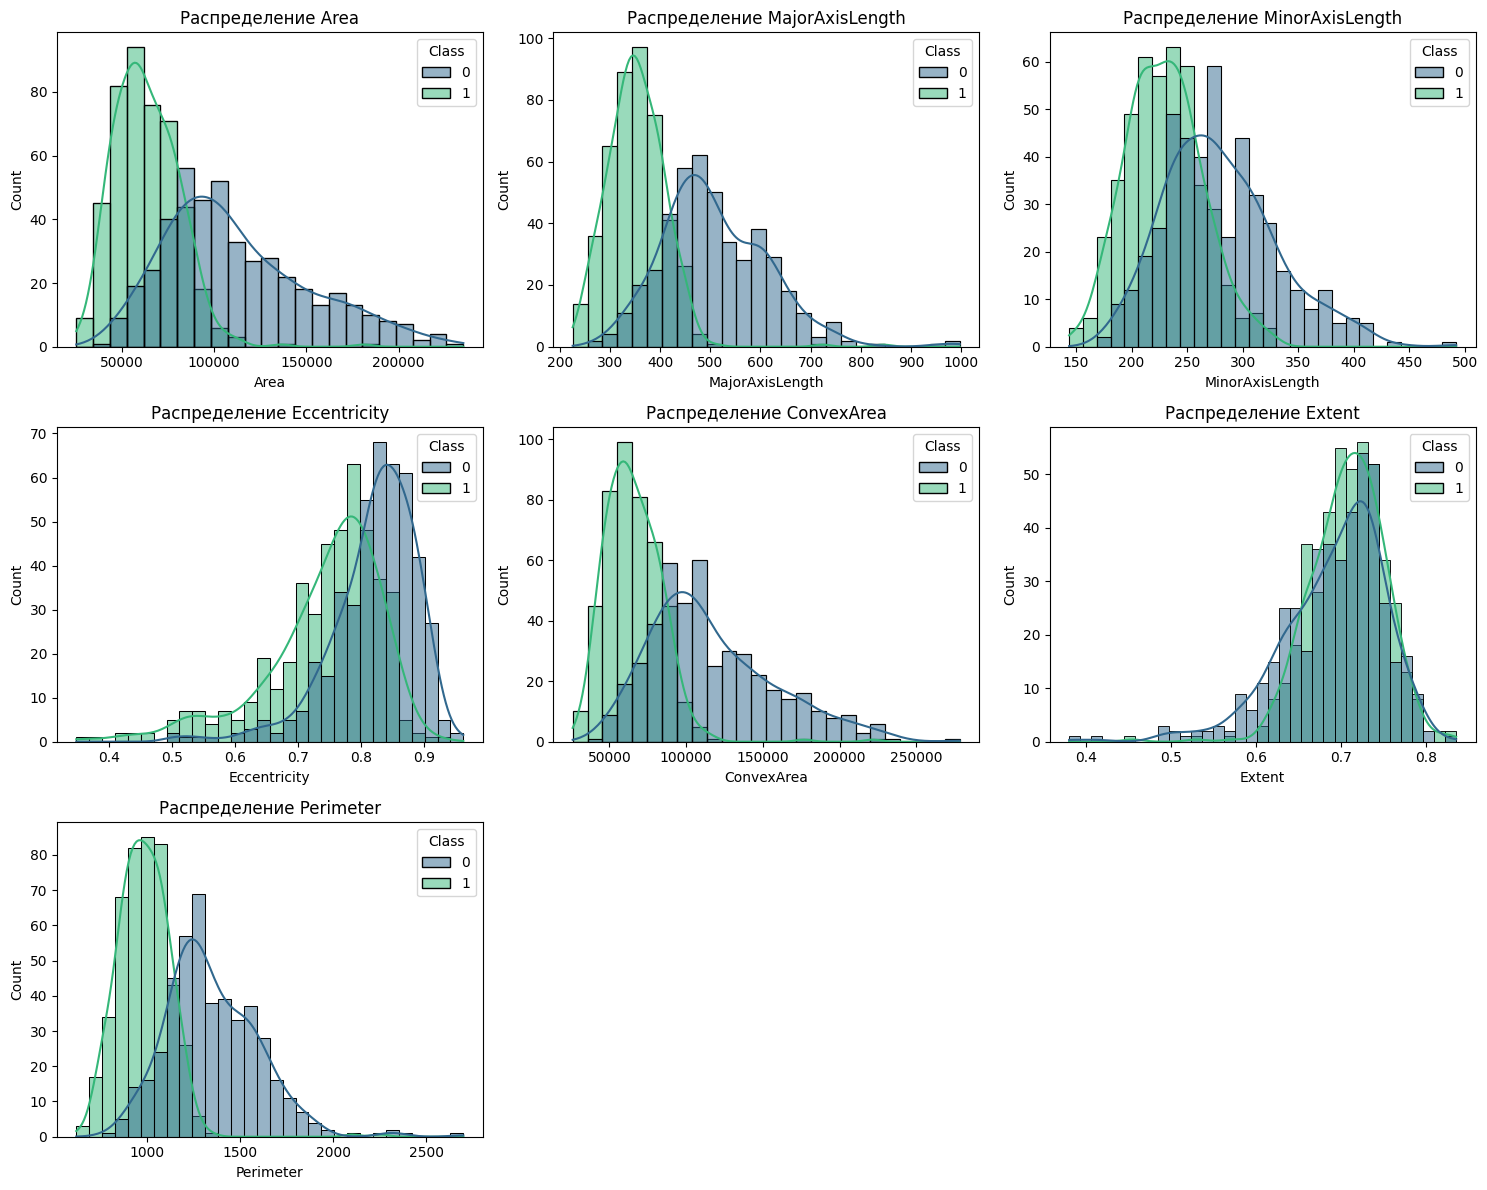

In [14]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Загружаем данные
raisin_df = pd.read_csv('Raisin_Dataset.csv')

# Посмотрим на первые строки и информацию
print("\nИнформация о датасете:")
raisin_df.info()

# Преобразуем текстовые метки классов в числовые (0 и 1)
le = LabelEncoder()
raisin_df['Class'] = le.fit_transform(raisin_df['Class'])
# Посмотрим, какой класс чему соответствует: le.classes_ -> array(['Besni', 'Kecimen'], dtype=object)
# Besni -> 0, Kecimen -> 1

# Разделим признаки (X) и целевую переменную (y)
X = raisin_df.drop('Class', axis=1)
y = raisin_df['Class']

# Визуализация распределений признаков внутри каждого класса
features = X.columns
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(data=raisin_df, x=feature, hue='Class', kde=True, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Распределение {feature}')

# Скрываем лишние пустые графики
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

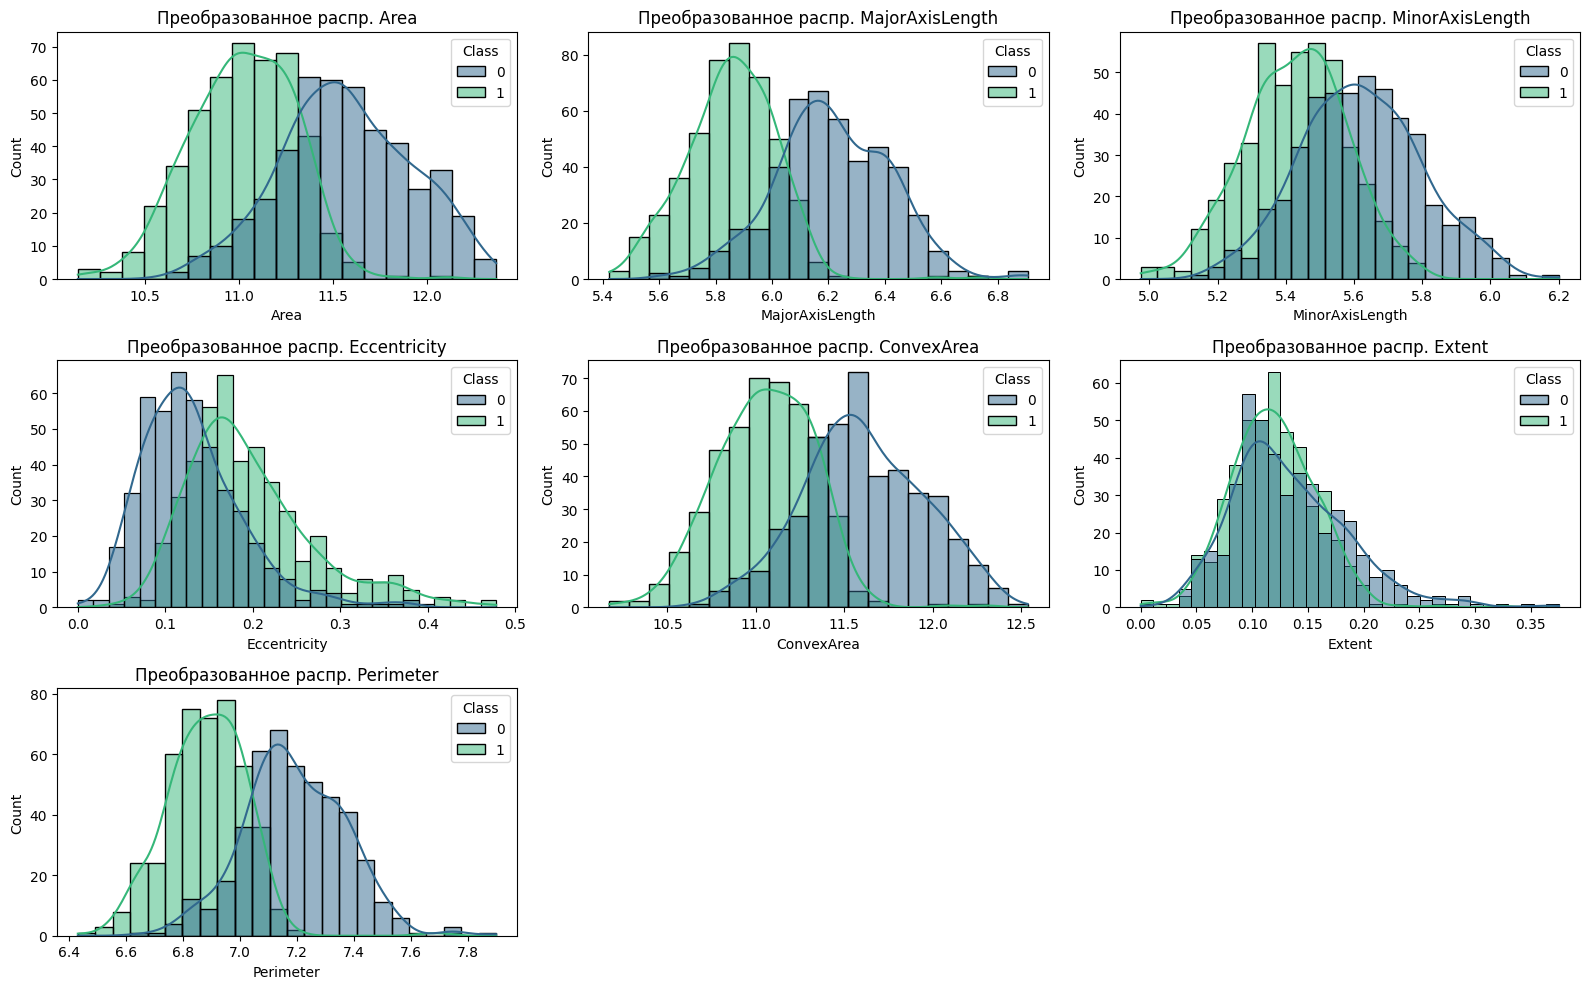

In [15]:
# Напомню, как мы создали X_transformed_correct
# Этот код уже должен был быть выполнен, но я привожу его для полноты
X_transformed_correct = X.copy()

# Признаки с ПРАВОСТОРОННЕЙ асимметрией
right_skewed = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'Perimeter']
for feature in right_skewed:
    X_transformed_correct[feature] = np.log1p(X[feature])

# Признаки с ЛЕВОСТОРОННЕЙ асимметрией
left_skewed = ['Eccentricity', 'Extent']
for feature in left_skewed:
    max_val = X[feature].max()
    reflected_feature = max_val - X[feature]
    X_transformed_correct[feature] = np.log1p(reflected_feature)

# --- А теперь визуализация ВСЕХ признаков ПОСЛЕ преобразования ---

features_transformed = X_transformed_correct.columns
n_features = len(features_transformed)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
axes = axes.flatten()

# Создаем временный датафрейм для удобства отрисовки с помощью seaborn
plot_df = pd.concat([X_transformed_correct, y], axis=1)

for i, feature in enumerate(features_transformed):
    sns.histplot(data=plot_df, x=feature, hue='Class', kde=True, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Преобразованное распр. {feature}')

# Скрываем лишние пустые графики, если они есть
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

как можно видеть, данные стали куда более нормальными. графики не ложаться прям явно друг на друга (кроме `MinorAxisLength` и `Extent`) (чем больше перекрытие, тем более бесполезен признак)
```
 Можно ли сразу по вашим графикам сказать, что предположения, нужные для какого-то из классификаторов, здесь совсем не выполняются?
```
Прежде всего хочу отметить, что важно каждому из классификаторов:
- все классификаторы предпологают, что данные будут нормализованными (на исходных графиках такого нет, не текущих, обработанных они куда лучше)
- LDA важно, чтобы разброс данных был одинаковый для всех классов (ширина горок). как можно видеть, ширина +- подобная
- QDA не требует равного разброса, как это просит LDA
- еще отличие Гауссовского и LDA c QDA -- первый смотрит на признаки независимо, а вторые, так сказать, в "компликсе"


# 2. Модели без калибровки

**2. Модели без калибровки**

Отделив 20% данных в тестовое множество, обучите NB, LDA и QDA. Вычислите accuracy, precision, recall, f1-score на тестовом множестве (можно сделать это с помощью `classification_report`, который печатает сразу много метрик)

In [16]:


# Шаг 1: Разделение данных
# Используем наши лучшие, корректно преобразованные данные X_transformed_correct
X = X_transformed_correct 
# y у нас уже определен ранее (целевая переменная)

# Делим данные на 80% для обучения и 20% для теста.
# random_state=42 гарантирует, что разделение будет всегда одинаковым, если мы перезапустим код.
# stratify=y гарантирует, что доля классов 0 и 1 в обучающей и тестовой выборках будет одинаковой.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]} объектов")
print(f"Размер тестовой выборки: {X_test.shape[0]} объектов")
print("-" * 30)

# Шаг 2 и 3: Обучение и оценка моделей

# Инициализируем модели
gnb = GaussianNB()
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

# Создаем словарь для удобства, чтобы не писать один и тот же код три раза
models = {
    "Gaussian Naive Bayes": gnb,
    "Linear Discriminant Analysis": lda,
    "Quadratic Discriminant Analysis": qda
}

# Проходим по каждой модели в словаре
for name, model in models.items():
    print(f"--- Результаты для модели: {name} ---")
    
    # Обучаем модель на тренировочных данных
    model.fit(X_train, y_train)
    
    # Делаем предсказания на тестовых данных
    y_pred = model.predict(X_test)
    
    # Выводим отчет с метриками
    print(classification_report(y_test, y_pred, target_names=['Besni (class 0)', 'Kecimen (class 1)']))
    print("\n")

Размер обучающей выборки: 720 объектов
Размер тестовой выборки: 180 объектов
------------------------------
--- Результаты для модели: Gaussian Naive Bayes ---
                   precision    recall  f1-score   support

  Besni (class 0)       0.92      0.80      0.86        90
Kecimen (class 1)       0.82      0.93      0.88        90

         accuracy                           0.87       180
        macro avg       0.87      0.87      0.87       180
     weighted avg       0.87      0.87      0.87       180



--- Результаты для модели: Linear Discriminant Analysis ---
                   precision    recall  f1-score   support

  Besni (class 0)       0.92      0.79      0.85        90
Kecimen (class 1)       0.82      0.93      0.87        90

         accuracy                           0.86       180
        macro avg       0.87      0.86      0.86       180
     weighted avg       0.87      0.86      0.86       180



--- Результаты для модели: Quadratic Discriminant Analysis ---

/Users/vladsuman/miniconda3/envs/lab2/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/vladsuman/miniconda3/envs/lab2/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


# Почему?
GNB получился даже лучше по результатам
и вероятно это связано с тем, что у нас много связанных данных ('Area', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'Perimeter')

Используя встроенные в эти классификаторы методы, вычислите также предсказываемые ими вероятности одного из классов, который мы обзовем положительным. Постройте кривые калибровки. Сделать это можно с помощью функции ниже, которую я украла из склерновского туториала и немного переделала, либо написав свою, более эстетичную версию. Будьте готовы прокомментировать увиденное и объяснить, что это за точки и как определяется, где их рисовать

In [17]:
def draw_3_calibrations(clf_list, y_test, n_bins):
    """
    clf_list - список из трех tuples вида (модель, 'имя', вектор предсказанных на тесте вероятностей)
    y_test - реальные метки теста
    n_bins - сколько точек в кривой
    """
    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(3, 3)
    colors = plt.get_cmap("Dark2")

    ax_calibration_curve = fig.add_subplot(gs[:2, :3])
    calibration_displays = {}
    for i, (clf, name, y_prob) in enumerate(clf_list):
        disp = CalibrationDisplay.from_predictions(y_test, y_prob, name=name, n_bins=n_bins, ax=ax_calibration_curve, color=colors(i))
        calibration_displays[name] = disp

    ax_calibration_curve.grid()
    ax_calibration_curve.set_title("Calibration plots")

    grid_positions = [(2, 0), (2, 1), (2, 2)]
    for i, (_, name, _) in enumerate(clf_list):
        row, col = grid_positions[i]
        ax = fig.add_subplot(gs[row, col])

        ax.hist(
            calibration_displays[name].y_prob,
            range=(0, 1),
            bins=10,
            label=name,
            color=colors(i),
        )
        ax.set(title=name, xlabel="Predicted probability", ylabel="Count")

    plt.tight_layout()
    plt.show()

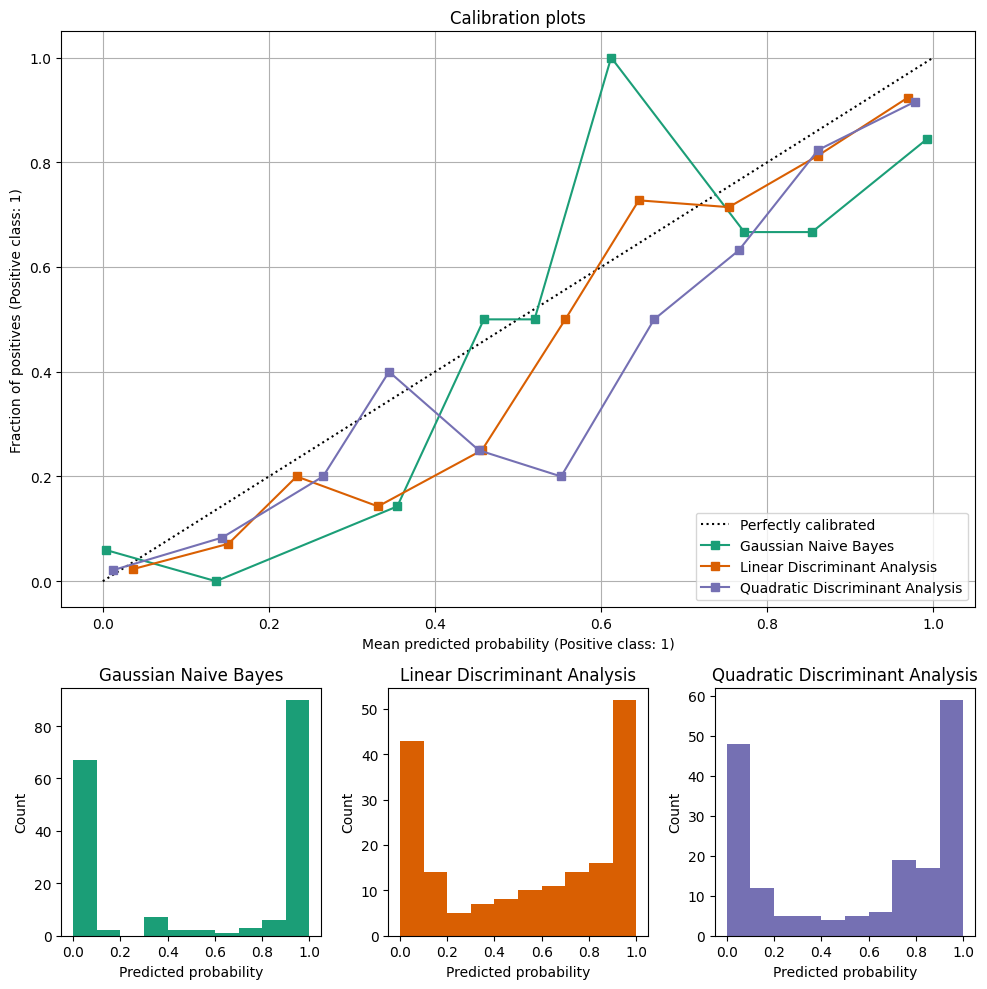

In [18]:
# Создаем пустой список, в который будем складывать данные для графика
clf_list = []

# Проходим по нашему словарю с уже обученными моделями
for name, model in models.items():
    # Шаг 1: Вычисляем вероятности для положительного класса (Kecimen, класс 1)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Добавляем в список кортеж в формате, который требует функция
    # (сама модель, ее имя, вектор вероятностей)
    clf_list.append((model, name, y_prob))

# Шаг 2: Вызываем функцию для отрисовки графиков
# n_bins=10 - это стандартное значение, которое хорошо подходит для начала
draw_3_calibrations(clf_list, y_test, n_bins=10)

```
Будьте готовы прокомментировать увиденное и объяснить, что это за точки и как определяется, где их рисовать
```
#### Как рисовать

1.  **Берем все предсказания модели.** У нас их 180 штук — это 180 чисел от 0 до 1 (например, 0.12, 0.87, 0.55, ...).
2.  **Делим все предсказания на "корзины" (bins).** Мы разбили диапазон [0, 1] на 10 корзин: [0, 0.1], [0.1, 0.2], ..., [0.9, 1.0].
3.  **Раскладываем предсказания по корзинам.** Например, предсказание 0.87 попадает в корзину [0.8, 0.9]. Предсказание 0.12 — в корзину [0.1, 0.2].
4.  **Считаем координаты для точки.** Для каждой корзины (например, для [0.8, 0.9]) мы вычисляем две вещи:
    *   **X-координата (горизонтальная ось):** *Средняя предсказанная вероятность* для всех объектов, попавших в эту корзину. Если туда попали предсказания 0.82, 0.87, 0.88, то среднее будет ~0.86.
    *   **Y-координата (вертикальная ось):** *Реальная доля положительных классов* среди этих же объектов. Если из трех объектов с предсказаниями 0.82, 0.87, 0.88 в реальности два были класса 1, а один — класса 0, то реальная доля будет 2/3 ≈ 0.67.
5.  **Ставим точку.** Мы ставим на график точку с координатами (X=0.86, Y=0.67).

#### Как интерпретировать график?

*   **Идеальная диагональ (пунктирная линия):** Это "идеально честный" классификатор. Если он предсказывает в среднем 0.8 (ось X), то и реальная доля правильных ответов составляет 0.8 (ось Y).
*   **Кривая НИЖЕ диагонали:** Модель **слишком самоуверенна (over-confident)**. Она говорит "я уверена на 80%", а на самом деле права только в 60% случаев.
*   **Кривая ВЫШЕ диагонали:** Модель **слишком неуверенна (under-confident)**. Она говорит "я уверена на 30%", а на самом деле права в 50% случаев.
*   **Гистограммы внизу:** Они показывают, какие вероятности модель предсказывает чаще всего. Если все столбики по краям (около 0 и 1), модель очень "решительная". Если все в центре (около 0.5), модель очень "неуверенная".


**3. Перекалибровка**

Для склерновских моделей перекалибровку вероятностей можно осуществить с помощью встроенного `CalibratedClassifierCV`. Сходите в справку и почитайте, что означает это CV и какие у него последствия. Для каждого базового классификатора обучите откалиброванный с методами `sigmoid` и `isotonic`, установив `ensemble=False`. Снова пересчитайте метрики и отрисуйте кривые калибровки (чтобы не громоздить их 9 штук на один рисунок, можете сделать 3 отдельных, по одному для каждой базовой модели)

Анализ калибровки для модели: Gaussian Naive Bayes

--- Метрики после Sigmoid калибровки ---
              precision    recall  f1-score   support

       Besni       0.91      0.81      0.86        90
     Kecimen       0.83      0.92      0.87        90

    accuracy                           0.87       180
   macro avg       0.87      0.87      0.87       180
weighted avg       0.87      0.87      0.87       180


--- Метрики после Isotonic калибровки ---
              precision    recall  f1-score   support

       Besni       0.91      0.81      0.86        90
     Kecimen       0.83      0.92      0.87        90

    accuracy                           0.87       180
   macro avg       0.87      0.87      0.87       180
weighted avg       0.87      0.87      0.87       180


--- Графики калибровки для Gaussian Naive Bayes ---


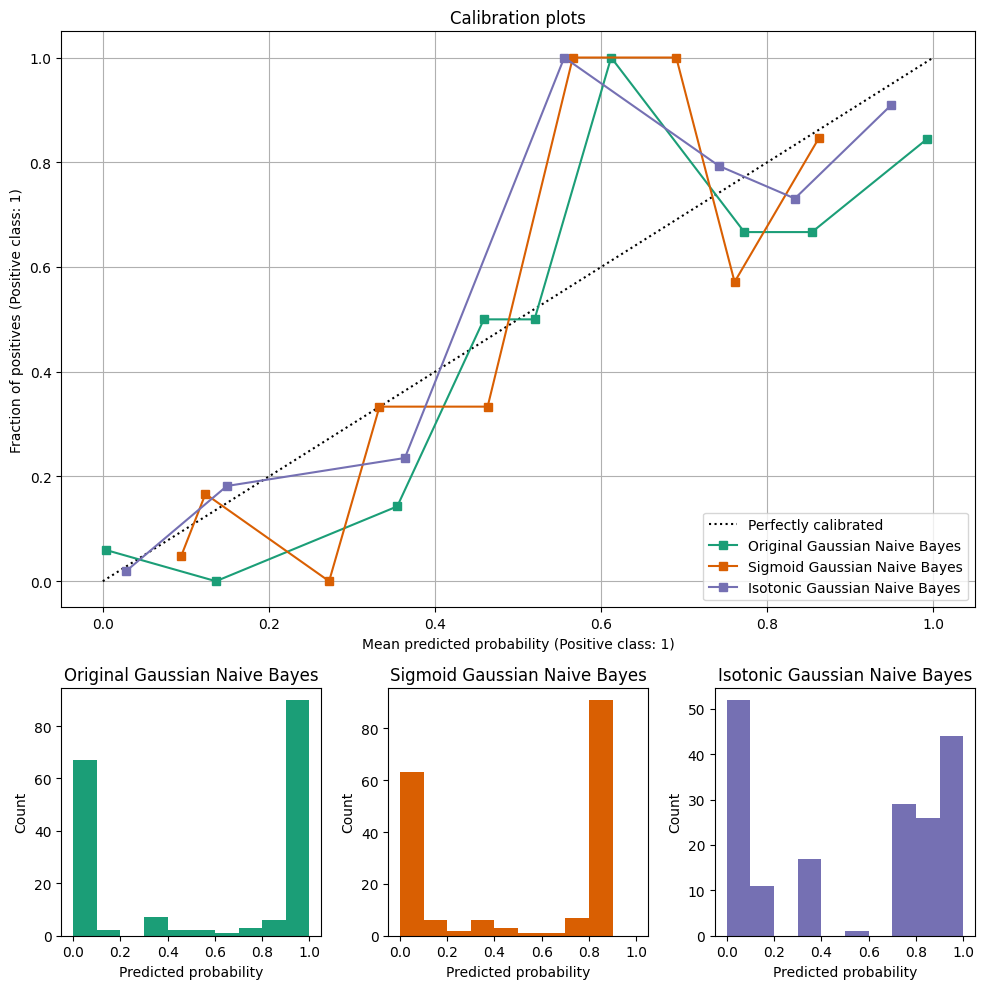

Анализ калибровки для модели: Linear Discriminant Analysis

--- Метрики после Sigmoid калибровки ---
              precision    recall  f1-score   support

       Besni       0.92      0.80      0.86        90
     Kecimen       0.82      0.93      0.88        90

    accuracy                           0.87       180
   macro avg       0.87      0.87      0.87       180
weighted avg       0.87      0.87      0.87       180


--- Метрики после Isotonic калибровки ---
              precision    recall  f1-score   support

       Besni       0.94      0.74      0.83        90
     Kecimen       0.79      0.96      0.86        90

    accuracy                           0.85       180
   macro avg       0.87      0.85      0.85       180
weighted avg       0.87      0.85      0.85       180


--- Графики калибровки для Linear Discriminant Analysis ---


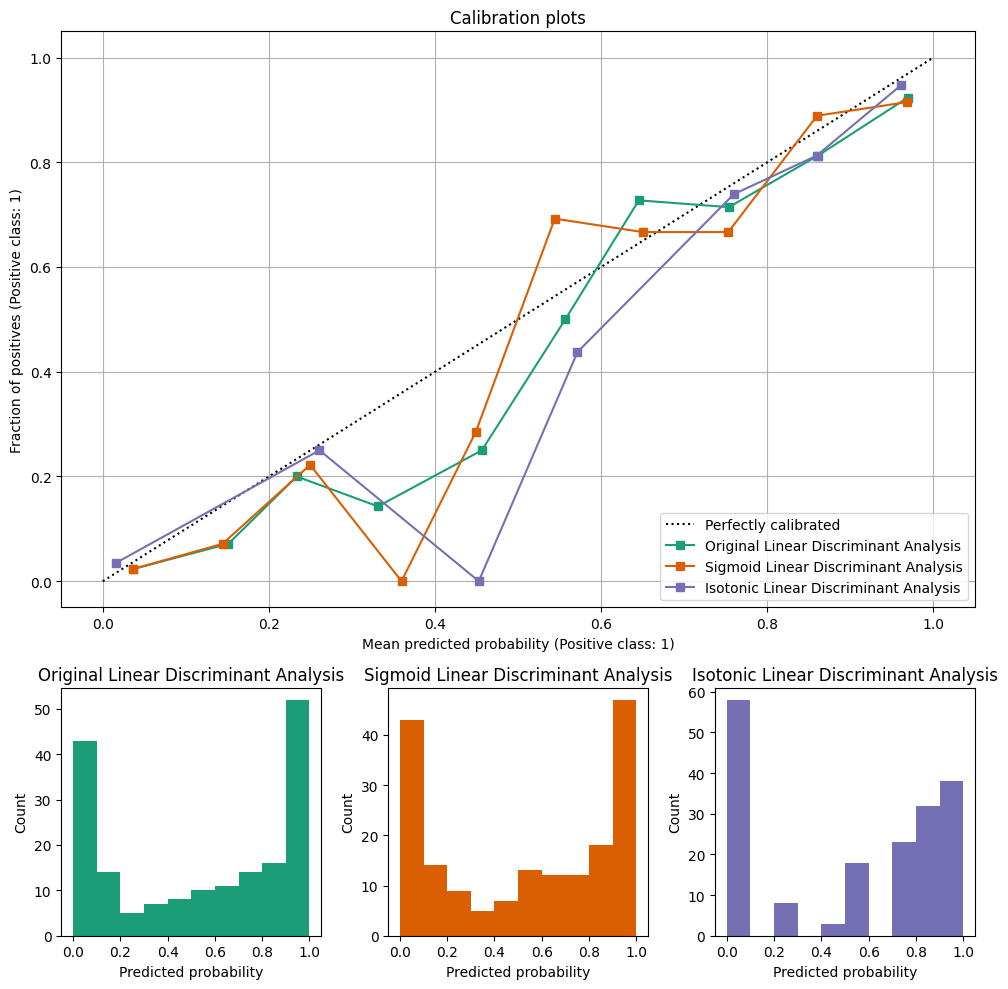

Анализ калибровки для модели: Quadratic Discriminant Analysis

--- Метрики после Sigmoid калибровки ---
              precision    recall  f1-score   support

       Besni       0.93      0.73      0.82        90
     Kecimen       0.78      0.94      0.85        90

    accuracy                           0.84       180
   macro avg       0.85      0.84      0.84       180
weighted avg       0.85      0.84      0.84       180


--- Метрики после Isotonic калибровки ---
              precision    recall  f1-score   support

       Besni       0.92      0.78      0.84        90
     Kecimen       0.81      0.93      0.87        90

    accuracy                           0.86       180
   macro avg       0.86      0.86      0.85       180
weighted avg       0.86      0.86      0.85       180


--- Графики калибровки для Quadratic Discriminant Analysis ---


/Users/vladsuman/miniconda3/envs/lab2/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/vladsuman/miniconda3/envs/lab2/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/vladsuman/miniconda3/envs/lab2/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/vladsuman/miniconda3/envs/lab2/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasin

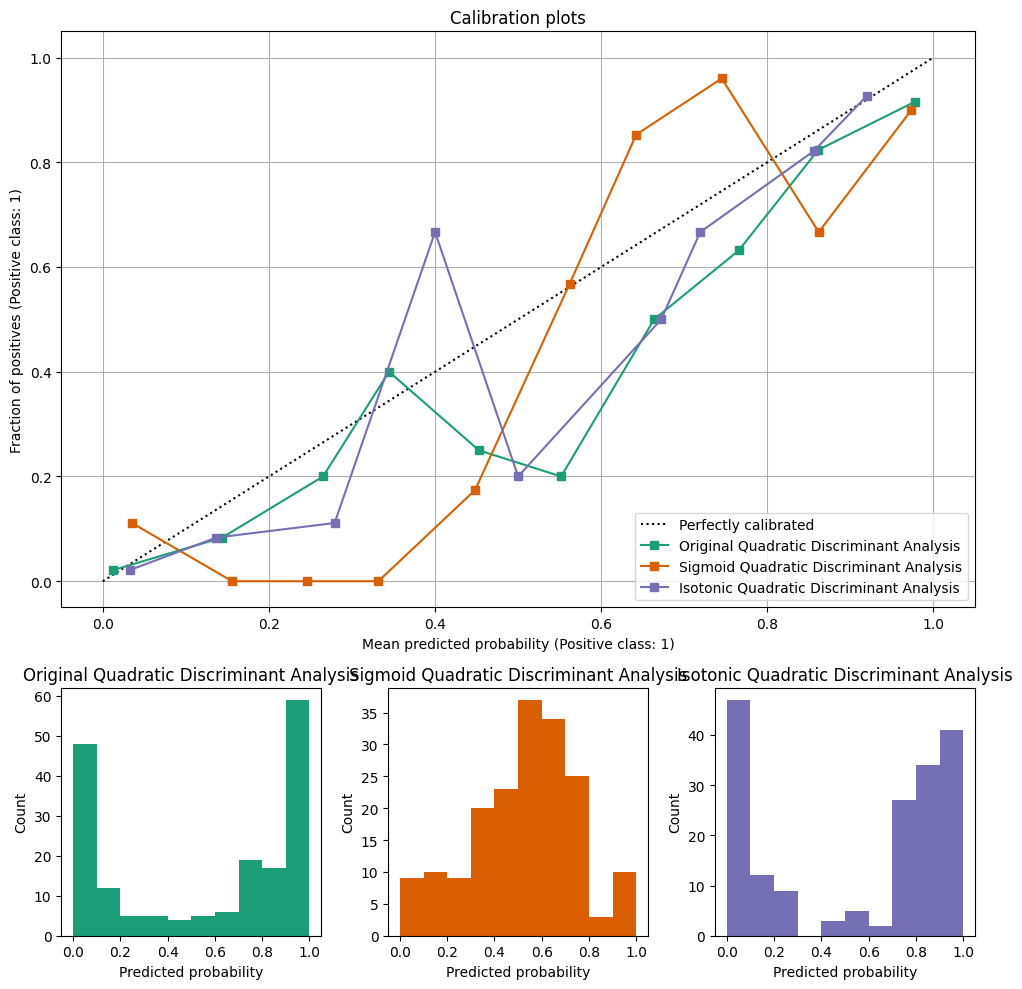

In [19]:
from sklearn.calibration import CalibratedClassifierCV

# Проходим по нашему словарю с уже обученными моделями
# models = {"Gaussian Naive Bayes": gnb, "Linear Discriminant Analysis": lda, ...}
for name, model in models.items():
    print(f"========================================================")
    print(f"Анализ калибровки для модели: {name}")
    print(f"========================================================")
    
    # Создаем два калибратора для текущей модели
    # cv=5 - стандартное значение для кросс-валидации
    calibrated_sigmoid = CalibratedClassifierCV(
        model, method='sigmoid', cv=5, ensemble=False
    )
    calibrated_isotonic = CalibratedClassifierCV(
        model, method='isotonic', cv=5, ensemble=False
    )
    
    # Обучаем оба калибратора на тренировочных данных
    calibrated_sigmoid.fit(X_train, y_train)
    calibrated_isotonic.fit(X_train, y_train)
    
    # --- Пересчитываем метрики ---
    print("\n--- Метрики после Sigmoid калибровки ---")
    pred_sigmoid = calibrated_sigmoid.predict(X_test)
    print(classification_report(y_test, pred_sigmoid, target_names=['Besni', 'Kecimen']))
    
    print("\n--- Метрики после Isotonic калибровки ---")
    pred_isotonic = calibrated_isotonic.predict(X_test)
    print(classification_report(y_test, pred_isotonic, target_names=['Besni', 'Kecimen']))
    
    # --- Готовим данные для графика ---
    # Получаем вероятности от некалиброванной и двух калиброванных моделей
    prob_original = model.predict_proba(X_test)[:, 1]
    prob_sigmoid = calibrated_sigmoid.predict_proba(X_test)[:, 1]
    prob_isotonic = calibrated_isotonic.predict_proba(X_test)[:, 1]
    
    # Собираем список для отрисовки (оригинал + 2 калиброванные версии)
    calibration_plot_list = [
        (model, f'Original {name}', prob_original),
        (calibrated_sigmoid, f'Sigmoid {name}', prob_sigmoid),
        (calibrated_isotonic, f'Isotonic {name}', prob_isotonic)
    ]
    
    # Рисуем график для текущей модели
    print(f"\n--- Графики калибровки для {name} ---")
    draw_3_calibrations(calibration_plot_list, y_test, n_bins=10)

Какой метод лучше откалибровал вероятности, если верить картинкам? Как калибровка повлияла на метрики - какому классификатору она была полезна, какому - не очень?

# Какой метод лучше откалибровал вероятности, если верить картинкам?
- GNB - Isotonic
- LDA - не помогла, а только ухудшила
- QDA - до конца не уверен, но будто бы без калибровки выглядело лучше 
# Как калибровка повлияла на метрики
но если взгялнуть на метрики
- для GNB -- ничего не изменилось
- для LDA с Sigmoid показало небольшое, но улучшение (не сходится с тем, что я говорил о графиках выше)
- для QDA с Isotonic тоже стало немного лучше

## Часть 2: дисбаланс классов

"На самом деле таска угадывания оттока\мошеннических операций по картам\кто не отдаст долг - это максимально типичная задача которая решается в жизни на каждом шагу половиной компаний у себя - поэтому нам надо это тоже посмотреть чтобы хотя бы примерно прикоснуться к тому с чем есть шанс работать в будущем" - сказал по этому поводу ваш прошлый преподаватель

**1. Предобработка** 

Загрузите данные (источник https://www.kaggle.com/datasets/blastchar/telco-customer-churn). Проверьте на наличие пропусков, определите, какие признаки категориальные, а какие - числовые. Предсказывать мы собираемся Churn

In [25]:
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import GridSearchCV

In [26]:
# если вы увидели расширение xls и попробовали прочитать это как эксель, возможно, у вас не получилось
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')
df.iloc[0]

customerID                7590-VHVEG
gender                        Female
SeniorCitizen                      0
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                      No
MultipleLines       No phone service
InternetService                  DSL
OnlineSecurity                    No
OnlineBackup                     Yes
DeviceProtection                  No
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 29.85
TotalCharges                   29.85
Churn                             No
Name: 0, dtype: object

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Табличка выше могла ввести нас в заблуждение. Обратите особое внимание на колонку TotalCharges. Осознав, что с ней не так, пересмотрите свои выводы по пропускам и категориальности остальных колонок.

In [28]:
# Удаляем строки, где TotalCharges является пропуском
df.dropna(inplace=True)

# Проверяем, что пропусков не осталось
print(f"\nКоличество пропусков после удаления: {df['TotalCharges'].isnull().sum()}")
print(f"Новый размер датафрейма: {df.shape}")


Количество пропусков после удаления: 0
Новый размер датафрейма: (7043, 21)


Посмотрите на дисбаланс классов, на расположение пропусков, на другие потенциально связанные с этими пропусками колонки и решите, что вы хотите с ними делать


Распределение классов (Churn):
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


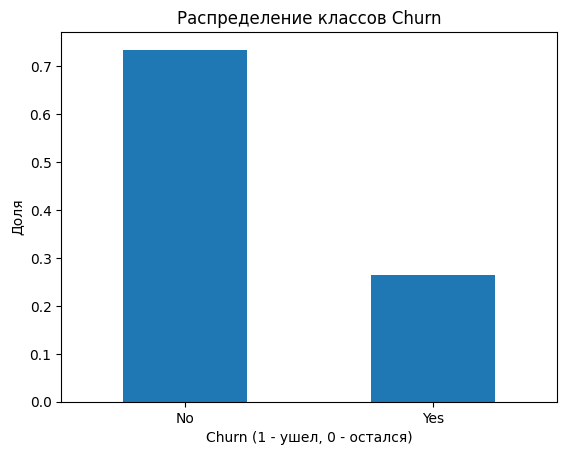

In [29]:
churn_distribution = df['Churn'].value_counts(normalize=True)
print("\nРаспределение классов (Churn):")
print(churn_distribution)

churn_distribution.plot(kind='bar', title='Распределение классов Churn')
plt.xlabel('Churn (1 - ушел, 0 - остался)')
plt.ylabel('Доля')
plt.xticks(rotation=0)
plt.show()

Сделав все, что хотели, поделите данные на трейн и тест и проверьте, что соотношения классов в них примерно одинаковы

In [30]:
from sklearn.model_selection import train_test_split


# Преобразование TotalCharges и удаление пропусков
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Преобразование Churn в 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Удаление customerID
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# ----------------------------------------------------------------

# Определяем признаки (X) и целевую переменную (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Делим данные на трейн и тест
# test_size=0.2
# random_state=42 для воспроизводимости
# stratify=y для сохранения баланса классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Проверяем результат
print("--- Соотношение классов в обучающей выборке ---")
print(y_train.value_counts(normalize=True))

print("\n--- Соотношение классов в тестовой выборке ---")
print(y_test.value_counts(normalize=True))

print("\n--- Исходное соотношение классов ---")
print(y.value_counts(normalize=True))

--- Соотношение классов в обучающей выборке ---
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

--- Соотношение классов в тестовой выборке ---
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64

--- Исходное соотношение классов ---
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


**2. Логистическая регрессия** 

Предобработайте признаки, чтобы их можно было подавать в регрессию. Будет ли колонка `TotalCharges` избыточной или наоборот, потенциально полезной? Обратите внимание, что при one-hot кодировании вы почти наверняка создаете лишнюю колонку. Если вы не ожидаете, что в тестовых данных появится какая-то неизвестная прежде категория, то значение в одной one-hot колонке линейно выражается через значения в остальных. В `get_dummies` или `OneHotEncoder`'e есть аргумент, позволяющий лишнюю колонку убрать!

Загрузите `LogisticRegression` из sklearn и обучите ее без учета неравенства классов. Вычислите метрики на тестовом и тренировочном наборах: accuracy, precision, recall, f1, roc-auc. Вычислите те же метрики, просто предсказав везде, что "оттока нет", и сделайте вывод о том, какие из них имеют ценность в данной задаче.

Постройте roc- и pr- кривые и объясните, что они такое, почему они так выглядят

- *для построения кривых у sklearn есть готовые функции, правда сами кривые они не рисуют, а только возвращают списки координат, которые надо будет подать в plot, и списки соответствующих границ. Что может быть даже полезно, потому что если бы они отдавали вам только картинки, то вы не могли бы потом понять, какой границе соответствует та замечательная точка графика, где достигается такой хороший баланс между precision и recall*

### 1. Будет ли колонка `TotalCharges` избыточной или наоборот, потенциально полезной?

У нас есть три числовых признака:
1.  `tenure` — как долго клиент с нами (в месяцах).
2.  `MonthlyCharges` — сколько клиент платит в месяц.
3.  `TotalCharges` — сколько клиент заплатил за все время.

Эти три величины сильно связаны друг с другом. В идеале `TotalCharges` ≈ `tenure` * `MonthlyCharges`.

**Так избыточна ли она?**
Тут как посмотреть
*   Да, `TotalCharges` сильно коррелирует с двумя другими признаками. Для линейных моделей, таких как логистическая регрессия, сильная мультиколлинеарность может делать веса модели нестабильными и трудно интерпретируемыми. Если бы мы хотели построить модель для **объяснения** причин оттока (т.е. понять, какой признак на сколько важен), то `TotalCharges` стоило бы удалить, чтобы сделать выводы о весах `tenure` и `MonthlyCharges` более надежными.

*   **Аргумент "ПРОТИВ" избыточности (почему она ПОЛЕЗНА):**
    1.  **Нелинейные эффекты:** Связь не всегда идеальна. Тарифные планы могут меняться, могут быть скидки, акции. `TotalCharges` может содержать в себе эту "историческую" информацию, которую не отражают два других признака. Например, клиент с большим `tenure` и низким `MonthlyCharges`, но высоким `TotalCharges` — это, вероятно, "старый" клиент, который раньше платил больше, а потом перешел на дешевый тариф. Эта информация может быть очень полезна для предсказания.
    2.  **Цель — предсказание, а не объяснение:** Наша главная цель в этой задаче — **максимально точное предсказание**, а не интерпретация весов. Современные реализации логистической регрессии (как в `sklearn`) используют регуляризацию (L1 или L2), которая очень эффективно борется с негативными эффектами мультиколлинеарности. Модель сама сможет "разобраться", как распределить веса между коррелирующими признаками, чтобы улучшить предсказание. Удаление потенциально полезного признака может ухудшить качество модели.


В контексте нашей задачи, где главная цель — **предсказание**, колонка `TotalCharges` является **потенциально полезной**, а не избыточной. Несмотря на ее сильную корреляцию с `tenure` и `MonthlyCharges`, она может нести в себе дополнительную информацию об истории платежей клиента. Благодаря встроенным в `LogisticRegression` механизмам регуляризации, негативные эффекты от мультиколлинеарности минимизируются, и модель может использовать этот признак для улучшения качества предсказаний.


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve

# Разделим колонки в X_train и X_test на числовые и категориальные
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = X_train.columns.drop(numerical_features)

# --- Масштабирование числовых признаков ---
scaler = StandardScaler()

# Обучаем scaler ТОЛЬКО на обучающих данных, чтобы избежать утечки информации из теста
X_train_num_scaled = scaler.fit_transform(X_train[numerical_features])
# Применяем то же самое преобразование к тестовым данным
X_test_num_scaled = scaler.transform(X_test[numerical_features])

# Превращаем обратно в DataFrame для удобства
X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns=numerical_features, index=X_train.index)
X_test_num_scaled = pd.DataFrame(X_test_num_scaled, columns=numerical_features, index=X_test.index)

# --- Кодирование категориальных признаков ---
# drop_first=True убирает первую категорию, чтобы избежать коллинеарности
X_train_cat_ohe = pd.get_dummies(X_train[categorical_features], drop_first=True, dtype=float)
X_test_cat_ohe = pd.get_dummies(X_test[categorical_features], drop_first=True, dtype=float)

# --- Объединяем все в готовые датасеты ---
X_train_processed = pd.concat([X_train_num_scaled, X_train_cat_ohe], axis=1)
X_test_processed = pd.concat([X_test_num_scaled, X_test_cat_ohe], axis=1)

print("Данные подготовлены. Количество признаков после OHE:", X_train_processed.shape[1])

Данные подготовлены. Количество признаков после OHE: 30


In [32]:
# Инициализируем модель. random_state для воспроизводимости, max_iter чтобы избежать предупреждений о несходимости
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Обучаем на подготовленных тренировочных данных
log_reg.fit(X_train_processed, y_train)

# Делаем предсказания на тестовых данных
y_pred_lr = log_reg.predict(X_test_processed)
y_prob_lr = log_reg.predict_proba(X_test_processed)[:, 1] # Вероятности для положительного класса

# --- Оценка модели ---
print("--- Отчет по метрикам для Логистической Регрессии ---")
print(classification_report(y_test, y_pred_lr))

print(f"ROC-AUC score: {roc_auc_score(y_test, y_prob_lr):.4f}")

# --- Сравнение с "глупой" моделью ---
import numpy as np
# Создаем предсказания, где все клиенты остаются (класс 0)
y_pred_dummy = np.zeros_like(y_test)

print("\n--- Отчет по метрикам для 'глупой' модели (всегда предсказывает 'No Churn') ---")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

--- Отчет по метрикам для Логистической Регрессии ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC score: 0.8361

--- Отчет по метрикам для 'глупой' модели (всегда предсказывает 'No Churn') ---
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1033
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



### 2. Вычислите те же метрики, просто предсказав везде, что "оттока нет", и сделайте вывод о том, какие из них имеют ценность в данной задаче.

Этот вопрос помогает нам понять, почему стандартные метрики могут быть обманчивы.

**Анализ результатов (из вашего вывода):**

| Метрика | "Глупая" модель (всегда 0) | Ваша Лог. Регрессия |
| :--- | :--- | :--- |
| **Accuracy** | **0.73** (73%) | **0.80** (80%) |
| **Precision (для класса 1)** | 0.00 | 0.65 |
| **Recall (для класса 1)** | 0.00 | 0.57 |
| **F1-score (для класса 1)** | 0.00 | 0.61 |
| **ROC-AUC** | 0.50 (по определению) | 0.84 |

**Выводы о ценности метрик:**

1.  **Accuracy — обманчива и почти бесполезна.** "Глупая" модель, которая не делает никакой полезной работы, уже имеет accuracy 73%. Наш прирост до 80% выглядит не так уж и впечатляюще на этом фоне. В задачах с дисбалансом классов ориентироваться на accuracy — плохая идея, так как она сильно смещена в пользу мажоритарного класса.

2.  **Precision, Recall и F1-score для миноритарного класса (Churn=1) — ключевые метрики.** "Глупая" модель имеет по ним нули, потому что она **никогда не находит** интересующий нас класс "ушедших" клиентов. Наша модель показывает здесь значимые, ненулевые результаты. Именно по этим метрикам мы можем судить о реальной пользе модели. Они показывают, насколько хорошо модель решает задачу **обнаружения** редкого события.

3.  **ROC-AUC — очень ценная сводная метрика.** Она показывает общую разделительную способность модели, независимо от выбранного порога. Значение 0.5 для "глупой" модели (которая не может разделить классы) и 0.84 для нашей — это яркое доказательство того, что наша модель действительно научилась отличать два класса друг от друга.

**Итоговый ответ:**

В задаче предсказания оттока с сильным дисбалансом классов **наибольшую ценность** имеют метрики, оценивающие качество работы с миноритарным классом (Churn=1), а именно **Precision, Recall и F1-score**. Также очень важной является интегральная метрика **ROC-AUC**, которая показывает общую способность модели ранжировать клиентов по степени риска оттока. В то же время, метрика **Accuracy** является **вводящей в заблуждение** и не должна использоваться как основной критерий оценки качества модели.

- Accuracy: "Глупая" модель имеет accuracy ~73% (просто угадывая самый частый класс). Наша модель имеет accuracy >80%. Это уже хорошо, мы точно лучше, чем случайность.
- Precision, Recall, F1-score для класса 1 (Churn='Yes'): Вот где самая важная информация! "Глупая" модель имеет 0 по всем этим метрикам. Она никогда не находит ушедших клиентов. Наша модель имеет здесь ненулевые значения. Это доказывает, что наша модель действительно чему-то научилась.
- Вывод о ценности метрик: В задаче с дисбалансом классов accuracy — плохая, обманчивая метрика. Нам нужно смотреть на precision, recall и f1-score для миноритарного (редкого) класса (в нашем случае, класса 1), а также на ROC-AUC.

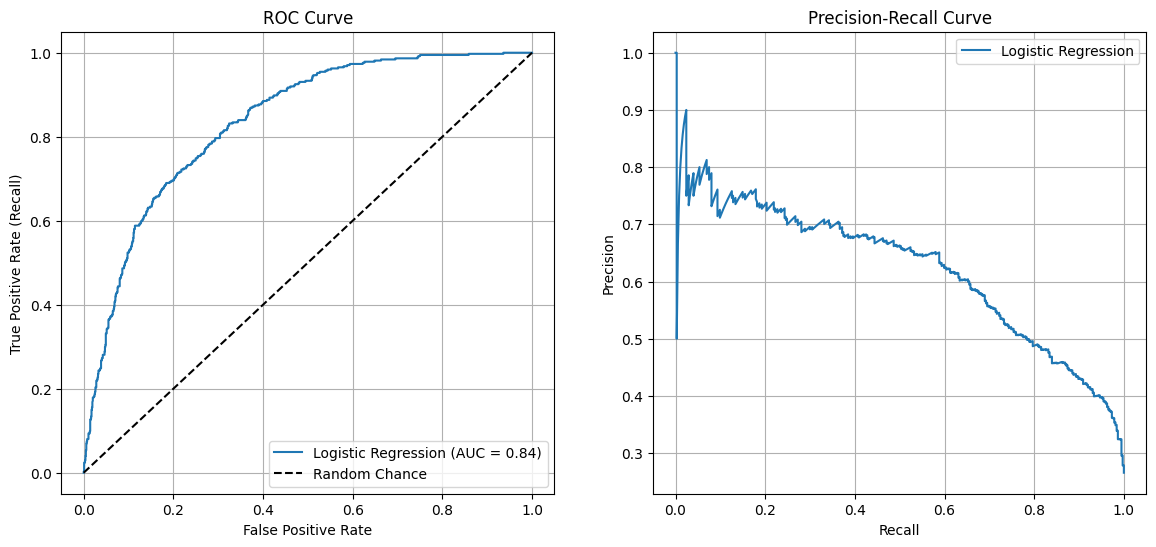

In [33]:
# Получаем данные для кривых
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_lr)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob_lr)

# Рисуем графики
plt.figure(figsize=(14, 6))

# ROC-кривая
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid()

# PR-кривая
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label='Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()

plt.show()

# ROC
- Что она показывает? Эта кривая показывает, насколько хорошо модель умеет отличать "ушедших" клиентов (класс 1) от "оставшихся" (класс 0). По оси Y — доля правильно найденных ушедших клиентов (Recall). По оси X — доля клиентов, которых модель ошибочно назвала ушедшими.
- Форма кривой: Ваша кривая сильно изгибается вверх и влево, далеко от диагональной пунктирной линии ("случайное угадывание"). Это очень хороший знак. Он говорит о том, что модель действительно нашла в данных полезные закономерности.
- AUC = 0.84: Площадь под кривой (Area Under Curve) равна 0.84. Это можно интерпретировать так: если взять случайного ушедшего клиента и случайного оставшегося, то с вероятностью 84% ваша модель присвоит более высокую "вероятность ухода" именно тому клиенту, который действительно ушел. Это хороший, солидный результат для базовой модели.

# Precision-Recall
- Что она показывает? Эта кривая гораздо важнее для нашей задачи с дисбалансом. Она показывает компромисс между двумя целями:
    - Recall (полнота, ось X): Найти как можно больше из тех, кто реально ушел.
    - Precision (точность, ось Y): Когда мы говорим "этот клиент уйдет", быть как можно точнее и не ошибаться.
- Форма кривой: Мы видим классический ниспадающий тренд.
    - Слева (низкий Recall): Если мы хотим быть очень точными (Precision > 0.8), мы сможем найти только очень маленькую долю ушедших клиентов (Recall < 0.2). Модель будет находить только самых "очевидных" кандидатов на уход.
    - Справа (высокий Recall): Если мы хотим найти почти всех, кто ушел (Recall -> 1.0), наша точность сильно упадет (Precision < 0.3). Мы будем "хватать" всех подряд, включая большое количество лояльных клиентов, которых мы ошибочно пометим как "уходящих".
    - "Колено" кривой: В районе Recall от 0.4 до 0.6 Precision держится на уровне 0.6-0.7. Это может быть интересной рабочей зоной. Например, при Recall=0.5 (находим половину ушедших), Precision составляет около 0.65 (из 100 клиентов, помеченных как уходящие, 65 действительно уйдут).

- Кривая наглядно демонстрирует, что игнорирование дисбаланса классов имеет свою цену. Модель не может одновременно и находить много ушедших клиентов, и делать это с высокой точностью. Стандартный порог 0.5, который дает Recall ~0.57 и Precision ~0.65, может быть неоптимальным. В зависимости от бизнес-задачи (что для нас дороже: упустить уходящего клиента или зря потратить деньги на удержание лояльного?), мы могли бы сдвинуть порог, чтобы двигаться по этой кривой влево или вправо.

**3. Дисбаланс классов** 

Когда мы выводили формулы для логистической регрессии, мы использовали предоположение о равенстве классов ($P(y=0)=P(y=1)$). Допустим, на самом деле соотношение между классами $\frac{P(y=0)}{P(y=1)}=\alpha$, но мы это проигнорировали и вычислили $P(y=1|X)$ и log odds (это $z=\log \frac{P(y=1|X)}{P(y=0|X)}$, и оно говорит нам о том, где проходит разделяющая плоскость) по старой формуле. 

1) Выведите, в каком соотношении находятся эти значения вероятностей с "честными". Предложите, что изменить в обучении или инференсе, чтобы учесть дисбаланс классов и снова считать правильные вероятности. Запишите!

2) Спуститесь в глубину архивов исходного кода sklearn для логистической регрессии (попасть туда можно, нажав \[source\] на страничке справки). Там найдите древние свитки, на которых записано, как дисбаланс классов обрабатывается в `LogisticRegression`. Перепишите эти знания предков в ноутбук и попробуйте объяснить, почему было сделано именно так.

3) Выбравшись из архивов, переобучите регрессию уже с учетом дисбаланса классов и пересчитайте все те же метрики. Посмотрите на precision-recall кривую, оцените, следует ли вам сдвинуть threshold с 0.5 куда-то еще. На основании чего вы можете сделать такой вывод?

**Дальше будет задание где нам нужны все наши модели одновременно, так что не удаляйте их из памяти пока!**

- *Для перебора параметров вообще можно использовать `GridSearchCV` или `RandomizedSearchCV`. Однако он требует выбрать некоторую метрику для сравнения*
- *заметьте, что никто не запрещает вам поставить в `class_weight` какие угодно коэффициенты дисбаланса. Как знать, может, нужная вам метрика станет лучше, если вы соврете о степени дисбаланса?*
- *`f1_score` - выбор желающих усидеть на двух стульях. Но что если мы хотим усидеть на одном стуле немного больше, чем на втором: мы как бы подозреваем, что, например, recall, важнее, но все же не хотим упускать из виду precision? Существует `fbeta_score` - взвешенная версия*

In [ ]:
# как-то вот так это может работать, если вы хотите еспользовать ее в переборе параметров
fb = make_scorer(fbeta_score, beta=3)
grid = GridSearchCV(base_classifier, param_grid={...}, scoring=fb, cv=3)

**4. Обыкновенная регрессия**

Попробуйте решить задачу с помощью `RidgeClassifier` и сравните метрики с логистической регрессией. Может, не так плоха линейная регрессия на друх классах?

Нам в этой лабе понадобятся вероятности, а у `RidgeClassifier` их нет, разве что какие-то confidence scores. Чтобы не посылать вас обратно копаться в исходном коде, просто скажем, что наши вероятности будут считаться взятием сигмоиды от того, что вернула `decision_function`

**5. Наивный Байес** 

Хотелось бы опробовать наивный байесовский классификатор на этой задаче, раз уж для L/QDA она не очень подходит в силу кучи категорий, но вот беда: наши признаки и категориальные, и числовые. Казалось бы, в чем проблема, но похоже в sklearn до сих пор нет версии байеса, которая бы умела с таким работать. Ваши варианты:

- подумать, как можно собрать математически эквивалентную версию из `GaussianNB` и `CategoricalNB`
- написать свой NB с нуля
- установить вот эту имплементацию https://github.com/remykarem/mixed-naive-bayes/tree/master

Выбирая вариант, учтите, что дальше нам от этого классификатора потребуются не просто ответы, а вероятности, или их подобие. У sklearn классификаторы обычно имеют метод `predict_proba`. В mixed-naive-bayes он какой-то тоже есть.

Прежде чем приступать к обучению классификатора, можно проверить кое-что еще. Наши численные признаки. Если вы не выбрали писать свой собственный классификатор, то заметьте, что готовый ожидает, что численные признаки нормально распределены. Но так ли это? Что вы можете сделать? Стоит ли оно того?

*логистическая регрессия с сигмоидой конечно тоже была заинтересована в нормальном распределении, но нам все равно пришлось бы скормить ей кучу категориальных фичей, так что...*

Обучите байесовский классификатор, посчитайте метрики

- *Для кодирования категориальных признаков для байеса лучше подойдет не one-hot, а `OrdinalEncoder`. Сравните его также с `LabelEncoder`: в чем разница?*

**6. Калибровка вероятностей**

1) Для наших классификаторов (логистическая регрессия, линейная регрессия, байесовский) постройте кривые калибровки вероятностей и прокомментируйте. 

> Как выглядят кривые калибровки для очень неуверенного классификатора? Для очень уверенного, но дающего неправильные ответы?

2. Попробуйте поправить вероятности. Для этого вообще существует `CalibratedClassifierCV`. Ниже приведен пример использования - разберитесь, что это за аргументы.

> Каждый из трех классификаторов засуньте вместе с тренировочным множеством в калибровщик. Попробуйте как `sigmoid`, так и `isotonic`. Постройте scatter графики старых и новых вероятностей, опишите, что с ними стало после калибровки. Отрисуйе новые кривые калибровки вместе со старыми (опять же, можно сделать три графика, отдельный для каждого классификатора).

In [ ]:
base_lr = LogisticRegression(...)# тут внутрь можно прописать ваши параметры, которые вы хотите зафиксировать
sigmoid_lr = CalibratedClassifierCV(base_lr, cv=4, method='sigmoid', ensemble=False)

Если вы написали своего наивного байеса, я за него не отвечаю, а вот если воспользовались готовым, то сейчас столкнетесь с проблемой: он не совсем совместим с этой калибровочной оболочкой. В частности, оболочка не верит, что это вообще классификатор и это вызывает проблемы в процессе. Возможно, вы придумаете какое-то более элегантное решение. Если вы тоже не особо программист, то, полистав исходный код, могу предложить вам следующий костыль: выдать ему фальшивое удостоверение классификатора и парочку классов для нашего конкретного случая.

In [ ]:
class ConvincingMixedNB(MixedNB):
    def __init__(self, categorical_features=None, max_categories=None,
                 alpha=0.5, priors=None, var_smoothing=1e-9):
        MixedNB.__init__(self, categorical_features, max_categories, alpha, priors, var_smoothing)
        self.classes_ = np.array([0,1])
        self._estimator_type = 'classifier'

Пересчитайте метрики, сравните со старыми. Также перерисуйте precision-recall кривые и сравните со старыми. Увиденное объясните.

**7.** Здесь было задание про овер-андерсэмплинг, но возможно стоит сжалиться над вами и пропустить его. Просто знайте, что нито вам не запрещает попробовать на этом датасете всяческие сэмплинги и посмотреть, что будет!